# Heart DIsease EDA

# Importing Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

# importing Dataset

In [20]:
heart_disease = pd.read_csv(r"C:\Users\USER\Downloads\heartdisease.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# Data Structure inspection

In [21]:
## data types
heart_disease.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [22]:
## check for missing values and their count
heart_disease.isna().value_counts()
heart_disease.isnull().value_counts()

age    sex    cp     trestbps  chol   fbs    restecg  thalach  exang  oldpeak  slope  ca     thal   target
False  False  False  False     False  False  False    False    False  False    False  False  False  False     303
Name: count, dtype: int64

In [23]:
## statistical description
heart_disease.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# checking for correlation and relationship

<Axes: title={'center': 'Target Graphics'}, xlabel='Heart Disease', ylabel='Count'>

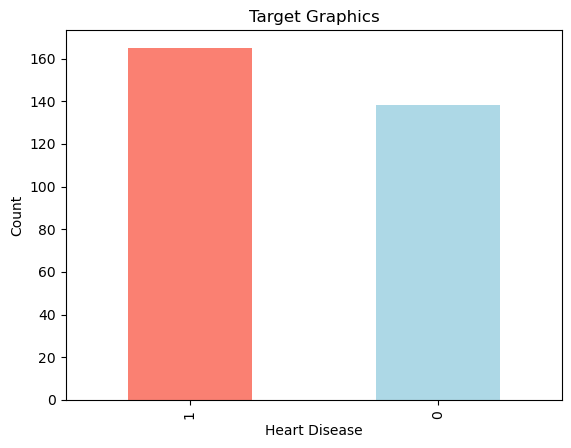

In [41]:
heart_disease["target"].value_counts().plot(kind="bar",
                                            color = ["salmon", "Lightblue"],
                                            xlabel = "Heart Disease",
                                            ylabel = "Count",
                                            title = "Target Graphics")
                            


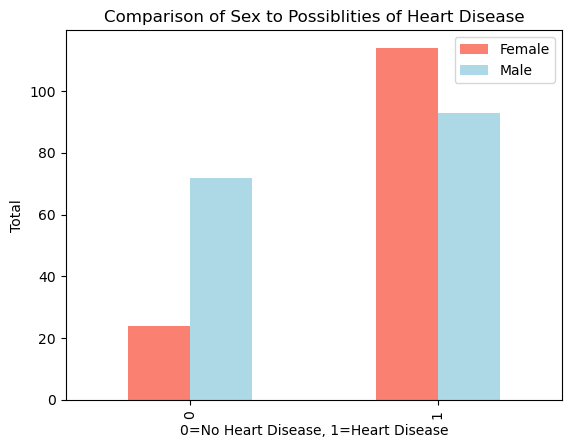

In [25]:
# finding patterns (comparison of sex having heart disease
pd.crosstab(heart_disease.sex, heart_disease.target).plot(kind = "bar",
                                                          color = ["salmon", "Lightblue"])
plt.title("Comparison of Sex to Possiblities of Heart Disease")
plt.xlabel("0=No Heart Disease, 1=Heart Disease")
plt.ylabel("Total")
plt.legend(["Female", "Male"])

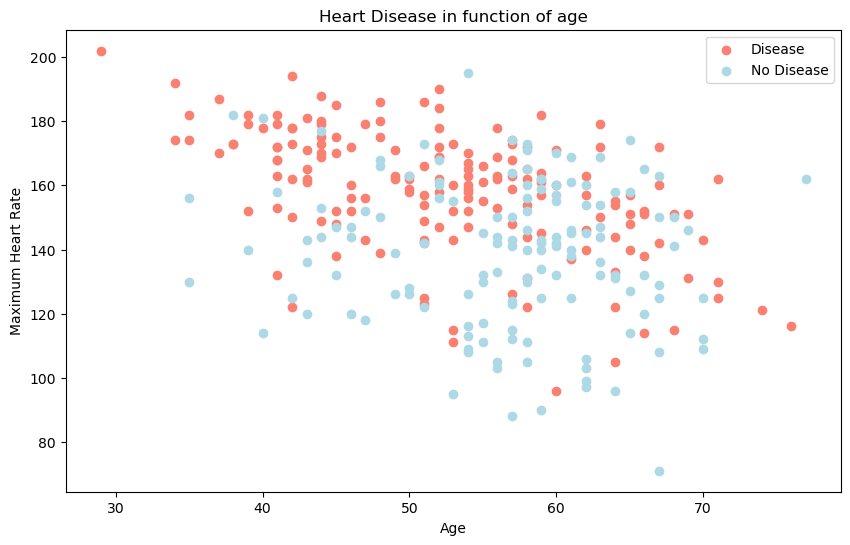

In [26]:
# Checking for correlation between Ages and Thalach
plt.figure(figsize=(10,6))
plt.scatter(heart_disease.age[heart_disease.target==1],
            heart_disease.thalach[heart_disease.target==1],
            color ="salmon")

plt.scatter(heart_disease.age[heart_disease.target==0],
            heart_disease.thalach[heart_disease.target==0],
            color ="Lightblue")
plt.title("Heart Disease in function of age")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.legend(["Disease", "No Disease"])

# Checking for Distribution

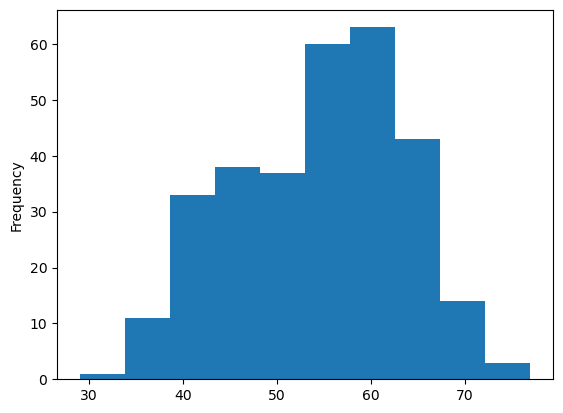

In [27]:
## Age Distribution
heart_disease.age.plot.hist();

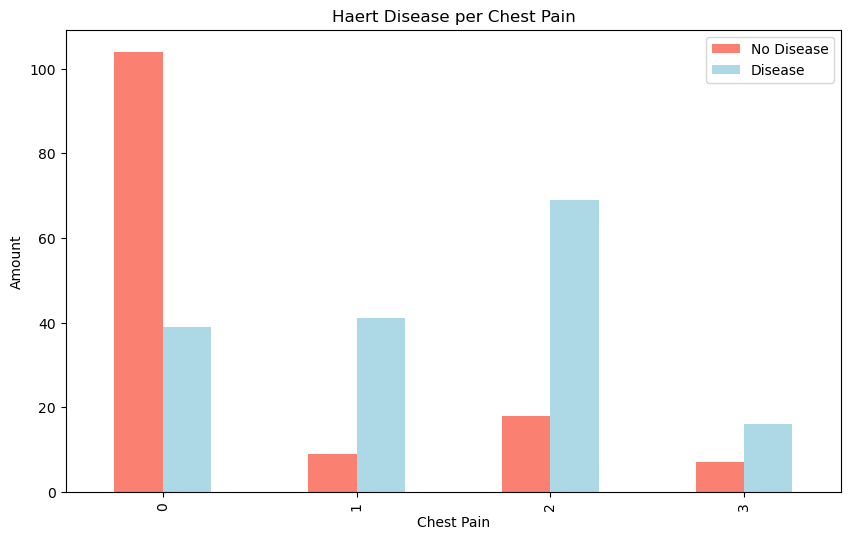

In [28]:
## Realtionship between Chest Pain and Heart Disease
pd.crosstab(heart_disease.cp, heart_disease.target).plot(kind ="bar",
                                                         figsize=(10,6),
                                                         color=["salmon", "Lightblue"])
plt.xlabel("Chest Pain")
plt.ylabel("Amount")
plt.title("Haert Disease per Chest Pain")
plt.legend(["No Disease", "Disease"])
#plt.xticks(Rotation=0);

In [29]:
## Correlation
hd_corr = heart_disease.corr()
hd_corr

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


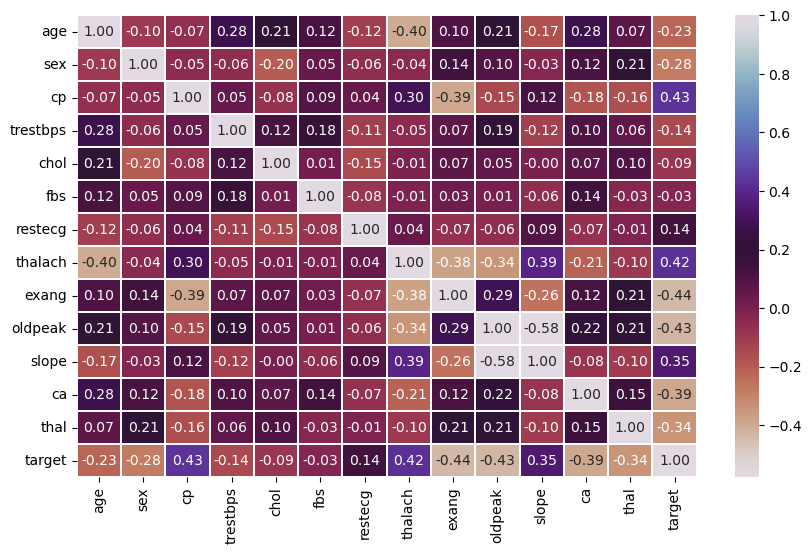

In [43]:
ax,fig = plt.subplots(figsize=(10,6))
ax = sns.heatmap(hd_corr, annot=True,
                 linewidths = 0.2,
                 fmt = "0.2f",
                 cmap="twilight_r");

# Building Machine Mode

In [31]:
## preparing tools for modelling

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import f1_score, precision_score, confusion_matrix, classification_report, recall_score, RocCurveDisplay

# Splitting of Datasets

In [32]:
heart_disease.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [33]:
x = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

## spliting of data to training and testing

np.random.seed(45)
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2)

In [34]:
## Training of machine model by comparing three machine model(KNN, LogisticRegression & RandomForest) for accuracy

models = {
    "KNN" : KNeighborsClassifier(),
    "Logistic Regression" : LogisticRegression(),
    "Random Forest" : RandomForestClassifier()


}

def model_compare(models, x_train,x_test,y_train,y_test):
    np.random.seed(45)
    model_score = {}
    for names, model in models.items():
        clf = model.fit(x_train, y_train)
        model_score[names] = clf.score(x_test,y_test)
    return model_score

In [144]:
m_compare = model_compare(models=models,
                           x_train = x_train,
                           y_train = y_train,
                           x_test = x_test,
                           y_test = y_test)
m_compare
                           
                           

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6721311475409836,
 'Logistic Regression': 0.9016393442622951,
 'Random Forest': 0.8852459016393442}

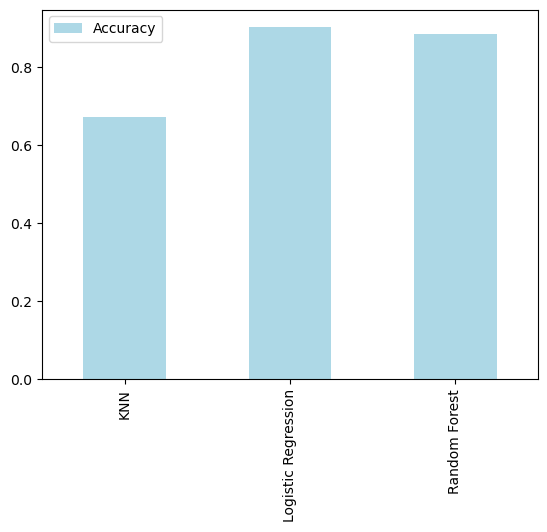

In [146]:
nf =pd.DataFrame(m_compare, index=["Accuracy"])
nf.T.plot.bar(color =["lightblue"]);

# Hyper Parameter Tuning

In [147]:
## Tuning K-Nearest Neighbor
train_score = []
test_score = []
## Creating a list of values for neigbors
neighbors = range(1,21)
## Setting up KNN instance
knn = KNeighborsClassifier()
## Looping through diffrent neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)
    #fit Algorithm
    knn.fit(x_train, y_train)

    train_score.append( knn.fit(x_train, y_train))
    train_score.append( knn.fit(x_test, y_test))
    

In [148]:
"""#c = len(neighbors) == len(train_score)
plt.plot(neighbors, train_score, label ="Train Score")
plt.plot(neighbors, test_score, label ="Test Score")

plt.xlabel("Number of Neighbors")
plt.ylabel("Model Score")
plt.legend()

plt.xticks(np.arrange(1,21,1))

print(f"The Maximum KNN score on Test Data is: {max(test_score)*100:.2f}%")
"""

"""# ✅ Fixed code
neighbors = []
train_score = []
test_score = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    neighbors.append(k)
    train_score.append(knn.score(X_train, y_train))  # one append each
    test_score.append(knn.score(X_test, y_test))

plt.plot(neighbors, train_score, label="Train Score")
plt.plot(neighbors, test_score, label="Test Score")
plt.xlabel("Number of Neighbors")
plt.ylabel("Score")
plt.legend()
plt.show()

"""

'# ✅ Fixed code\nneighbors = []\ntrain_score = []\ntest_score = []\n\nfor k in range(1, 21):\n    knn = KNeighborsClassifier(n_neighbors=k)\n    knn.fit(X_train, y_train)\n\n    neighbors.append(k)\n    train_score.append(knn.score(X_train, y_train))  # one append each\n    test_score.append(knn.score(X_test, y_test))\n\nplt.plot(neighbors, train_score, label="Train Score")\nplt.plot(neighbors, test_score, label="Test Score")\nplt.xlabel("Number of Neighbors")\nplt.ylabel("Score")\nplt.legend()\nplt.show()\n\n'

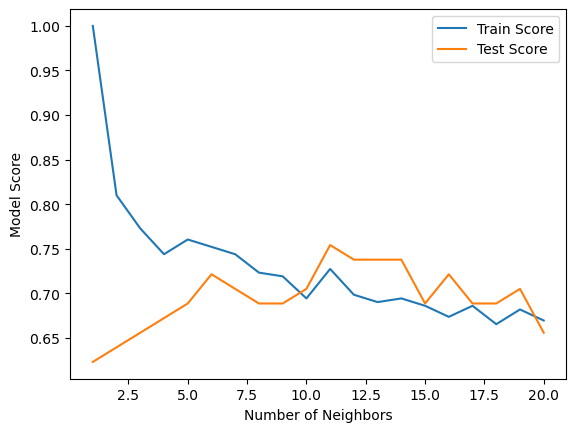

The Maximum KNN score on Test Data is: 75.41%


In [149]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# 1. Define your features and target first
x = heart_disease.drop(columns=["target"])  # replace with your actual target column name
y = heart_disease["target"]

# 2. Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Now run the loop
neighbors = []
train_score = []
test_score = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)

    neighbors.append(k)
    train_score.append(knn.score(x_train, y_train))
    test_score.append(knn.score(x_test, y_test))

# 4. Plot
plt.plot(neighbors, train_score, label="Train Score")
plt.plot(neighbors, test_score, label="Test Score")
plt.xlabel("Number of Neighbors")
plt.ylabel("Model Score")
plt.legend()
plt.show()

print(f"The Maximum KNN score on Test Data is: {max(test_score)*100:.2f}%")


In [150]:
## Tuning of Logistic Regression and RandomForest using RandomizedCV
## Creating parameter grid for Logistic regression

log_grid = {
    "C" : np.logspace(-4,4,20),
    "solver" : ["liblinear"]

}

## Creating parameter grid for Random Forest

rf = {
    "n_estimators" : np.arange(10,1000,50),
    "max_depth" : [None, 3, 5, 10],
    "min_samples_split" : np.arange(2,20,2),
    "min_samples_leaf" : np.arange(1,20,2)

}


In [151]:
##  Tuning of Logistic Regression using RandomizedCV

lrg = RandomizedSearchCV(LogisticRegression(),
                         param_distributions=log_grid,
                         cv=5,
                         n_iter=20,
                         verbose=True)

lrg.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [152]:
lrg.best_params_

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [153]:
lrg.score(x_test,y_test)

0.8852459016393442

In [154]:
# Tuning of RandomForest using RandomizedSearchCV

rf_cv = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf,
                           cv=5,
                           n_iter=20,
                           verbose=True)
rf_cv.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [155]:
rf_cv.best_params_

{'n_estimators': np.int64(560),
 'min_samples_split': np.int64(8),
 'min_samples_leaf': np.int64(9),
 'max_depth': 5}

In [156]:
rf_cv.score(x_test,y_test)

0.8688524590163934

In [160]:
## Tuning of Logistic Regression using GridSearchCV
lr_grid = {
    "C":np.logspace(-4,4,40),
    "solver": ["liblinear"]

}

lr_grid_cv = GridSearchCV(LogisticRegression(),
                          param_grid=lr_grid,
                          cv=5,
                          verbose=True)

lr_grid_cv.fit(x_train,y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,LogisticRegression()
,param_grid,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [161]:
lr_grid_cv.best_params_

{'C': np.float64(0.19144819761699575), 'solver': 'liblinear'}

In [162]:
lr_grid_cv.score(x_test,y_test)

0.8852459016393442

In [163]:
y_preds = lr_grid_cv.predict(x_test)
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

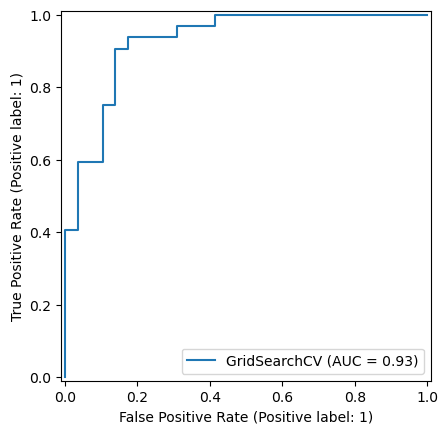

In [167]:
## Plot Roc curve and calculating AUC

#RocCurveDisplay(lr_grid_cv,
#               x_test,
#               y_test);

RocCurveDisplay.from_estimator(
    lr_grid_cv,   # your fitted estimator
    x_test,
    y_test
);

In [168]:
## Classification Report
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



# Feature Importance

In [169]:
clf = LogisticRegression(C = 0.19144819761699575,
                         solver = 'liblinear')

clf.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.19144819761699575
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [170]:
clf.coef_

array([[ 0.00289514, -0.83734908,  0.65352832, -0.01156816, -0.00164177,
         0.04176191,  0.30423714,  0.02451628, -0.58988442, -0.56503172,
         0.44063325, -0.6294746 , -0.6675462 ]])

In [172]:
feature_dict = dict(zip(heart_disease.columns, list(clf.coef_[0])))
feature_dict

{'age': np.float64(0.0028951351559151502),
 'sex': np.float64(-0.8373490797009958),
 'cp': np.float64(0.653528316967144),
 'trestbps': np.float64(-0.011568156986226312),
 'chol': np.float64(-0.0016417708690606172),
 'fbs': np.float64(0.041761907351426014),
 'restecg': np.float64(0.30423713956919934),
 'thalach': np.float64(0.024516277027431123),
 'exang': np.float64(-0.5898844247060081),
 'oldpeak': np.float64(-0.5650317191322727),
 'slope': np.float64(0.44063324777297636),
 'ca': np.float64(-0.6294745979364675),
 'thal': np.float64(-0.6675461979876488)}

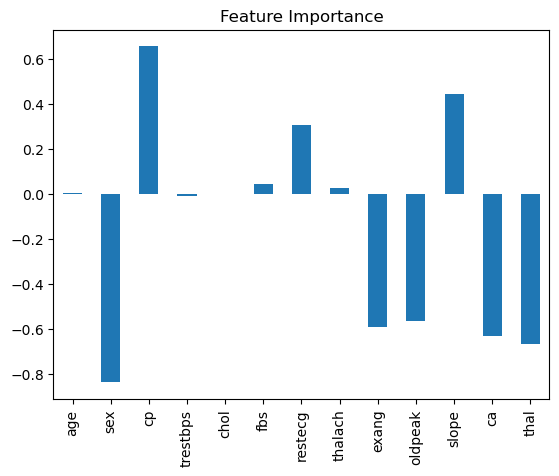

In [174]:
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(legend=False, title="Feature Importance");